In [34]:
import pandas as pd

## Preliminary Analysis

In [35]:
df = pd.read_csv('TSLA.csv')
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2019-05-21,39.551998,41.480000,39.208000,41.015999,90019500,0,0.0
1,2019-05-22,39.820000,40.787998,38.355999,38.546001,93426000,0,0.0
2,2019-05-23,38.868000,39.894001,37.243999,39.098000,132735500,0,0.0
3,2019-05-24,39.966000,39.995998,37.750000,38.125999,70683000,0,0.0
4,2019-05-28,38.240002,39.000000,37.570000,37.740002,51564500,0,0.0


In [36]:
ts = df[['Date', 'Close']]
ts.head()

,Date,Close
0,2019-05-21,41.015999
1,2019-05-22,38.546001
2,2019-05-23,39.098000
3,2019-05-24,38.125999
4,2019-05-28,37.740002


In [37]:
ts.isnull().sum()

Date     0
Close    0
dtype: int64

In [38]:
ts.dtypes

Date      object
Close    float64
dtype: object

In [39]:
ts['Date'] = pd.to_datetime(ts['Date'])

C:\Users\one more child\AppData\Local\Temp\ipykernel_7580\3970516155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ts['Date'] = pd.to_datetime(ts['Date'])


In [40]:
ts.dtypes

Date     datetime64[ns]
Close           float64
dtype: object

In [41]:
ts['Date']

0     2019-05-21
1     2019-05-22
2     2019-05-23
3     2019-05-24
4     2019-05-28
         ...    
753   2022-05-16
754   2022-05-17
755   2022-05-18
756   2022-05-19
757   2022-05-20
Name: Date, Length: 758, dtype: datetime64[ns]

## Trend Analysis

Text(0.5, 1.0, "Time Series for Tesla's Closing Stocks")

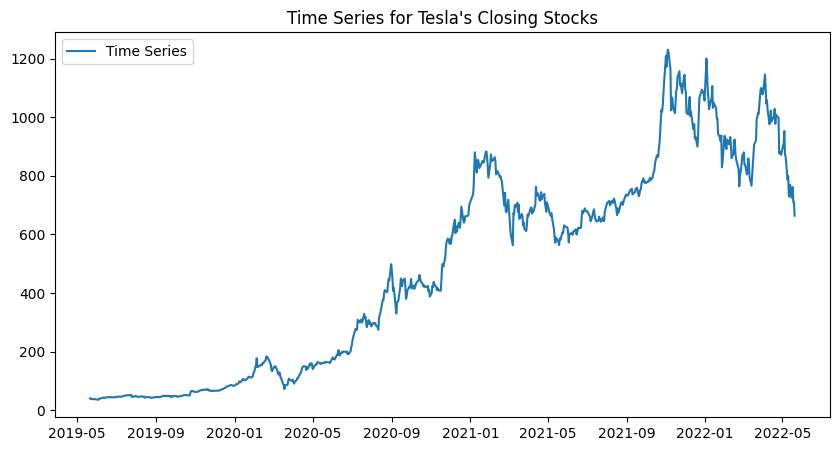

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(ts['Date'], ts['Close'], label='Time Series')
plt.legend()
plt.title("Time Series for Tesla's Closing Stocks")

There's a genral increase of the Tesla stock over time
Significant spikes occurred at the following years:
- 2020 towards 2021
- Towards end of 2021

Significant Declines in the following years:
- 2021 Feb - April
- 2022 May

<Figure size 1000x800 with 0 Axes>

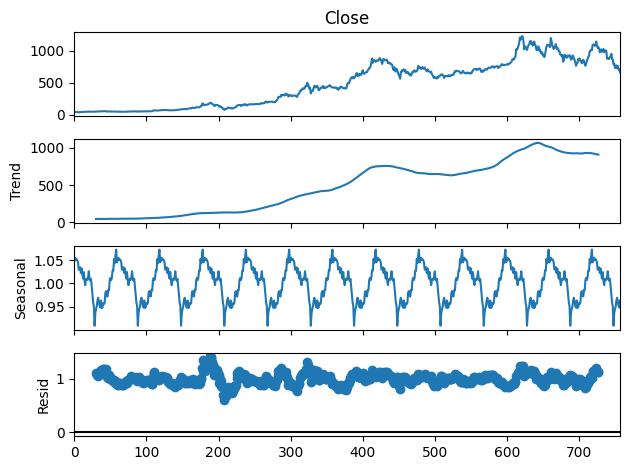

In [43]:
from statsmodels.tsa.seasonal import seasonal_decompose

multiplicative = seasonal_decompose(ts['Close'], model='multiplicative', period=60)

plt.figure(figsize=(10,8))
multiplicative.plot()
plt.show()

In [44]:
trend = multiplicative.trend
season = multiplicative.seasonal
residual = multiplicative.resid

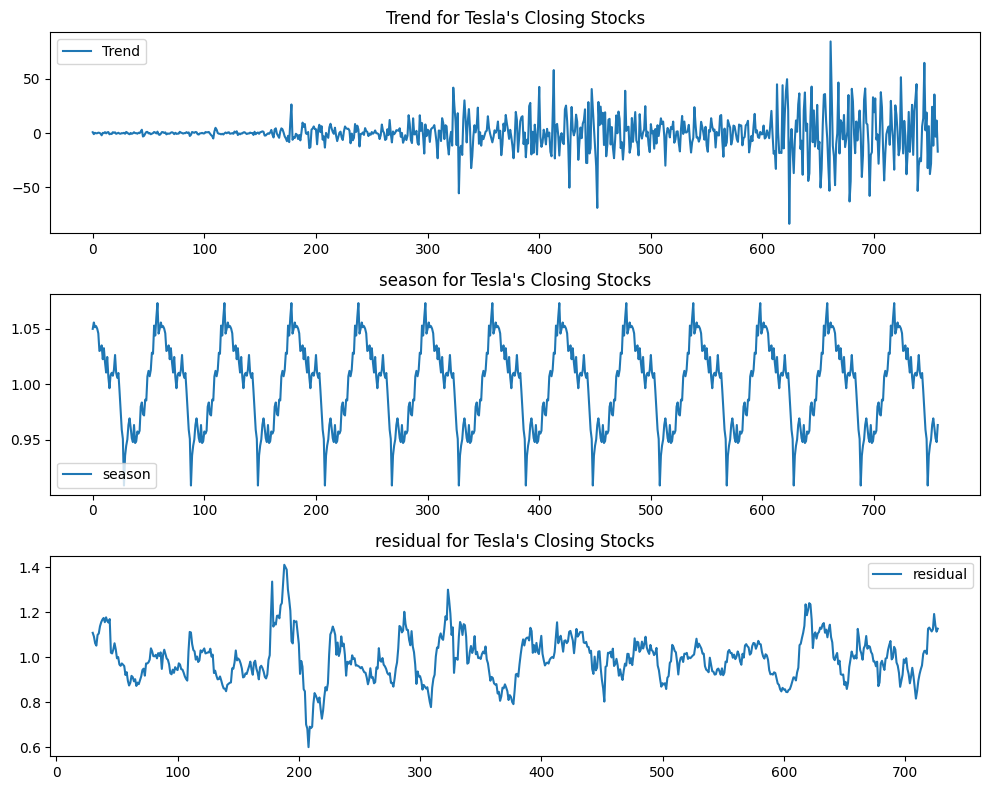

In [57]:
plt.figure(figsize=(10,8))

plt.subplot(3,1,1)
plt.plot(trend, label='Trend')
plt.legend()
plt.title("Trend for Tesla's Closing Stocks")

plt.subplot(3,1,2)
plt.plot(season, label='season')
plt.legend()
plt.title("season for Tesla's Closing Stocks")

plt.subplot(3,1,3)
plt.plot(residual, label='residual')
plt.legend()
plt.title("residual for Tesla's Closing Stocks")


plt.tight_layout()
plt.show()

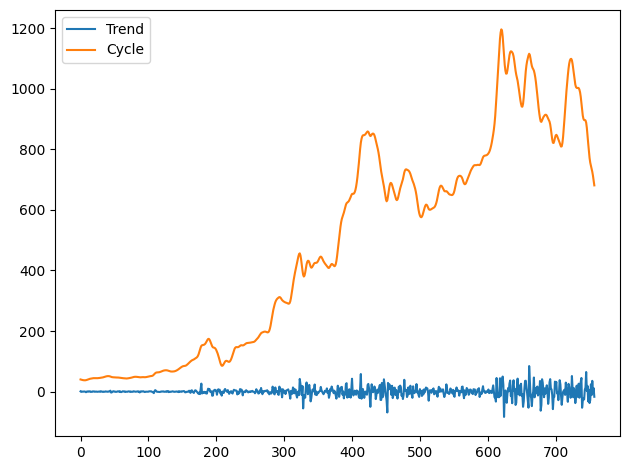

In [48]:
from statsmodels.tsa.filters.hp_filter import hpfilter

trend, cycle = hpfilter(ts['Close'], lamb=10)

plt.plot(trend, label='Trend')
plt.plot(cycle, label='Cycle')
plt.legend()
plt.tight_layout()
plt.show()

Trend is fluctuating around an avergae constant which is an indicator that the current stocks performance may is not good any cyclic opprotunities that may come in the stock